In [67]:
from pathlib import Path
import glob
import re

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, rdMolAlign, rdmolfiles
from rdkit.Chem import rdMolTransforms
import numpy as np

# Silence RDKit logs (explicit valence errors, sanitization warnings, etc.)
RDLogger.DisableLog('rdApp.*')


In [68]:
# for pdb_path in glob.glob("sampling/train_ref/*.pdb"):
#     pdb_num = int(re.search(r'(\d+).pdb', pdb_path).group(1))
#     mol = Chem.MolFromPDBFile(pdb_path)
#     Chem.MolToPDBFile(mol, f"sampling/test_{pdb_num}.pdb")

In [69]:
from rdkit.Chem import rdchem, rdmolops


def mol_to_match_key(mol, stereo=False):
    """
    Canonical SMILES with all explicit Hs and formal charges removed.
    Remove Hs first so heavy-atom valences are correct after charge zeroing.
    stereo=False strips stereo annotations for connectivity-only matching.
    """
    mol = Chem.RemoveHs(mol)
    rw = Chem.RWMol(mol)
    for atom in rw.GetAtoms():
        atom.SetFormalCharge(0)
    try:
        Chem.SanitizeMol(rw)
    except Exception:
        try:
            Chem.SanitizeMol(rw, Chem.SanitizeFlags.SANITIZE_ALL ^ Chem.SanitizeFlags.SANITIZE_PROPERTIES)
        except Exception:
            pass
    return Chem.MolToSmiles(rw.GetMol(), isomericSmiles=stereo, canonical=True)


def mol_to_exact_key(mol):
    """Canonical SMILES preserving charges and stereo — strictest match."""
    mol = Chem.RemoveHs(mol)
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        pass
    return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)


def canon_smi_from_mol(mol, stereo=True):
    """Canonical SMILES for display — same neutralization as matching key."""
    return mol_to_match_key(mol, stereo=stereo)


def load_pdb(path, perceive_stereo=False):
    mol = Chem.MolFromPDBFile(path, removeHs=True, sanitize=False)
    if mol is None:
        return None
    if not perceive_stereo:
        for atom in mol.GetAtoms():
            atom.SetChiralTag(rdchem.ChiralType.CHI_UNSPECIFIED)
        for bond in mol.GetBonds():
            bond.SetStereo(rdchem.BondStereo.STEREONONE)
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None
    if perceive_stereo:
        Chem.AssignStereochemistry(mol, cleanIt=False, force=True)
    return mol


def heavy_atom_rmsd(mol_ref, mol_gen):
    ref = Chem.RemoveHs(mol_ref)
    gen = Chem.RemoveHs(mol_gen)
    try:
        return rdMolAlign.GetBestRMS(ref, gen)
    except RuntimeError:
        return float('inf')


def bond_length_mae(mol_ref, mol_gen):
    mol_ref = Chem.RemoveHs(mol_ref)
    mol_gen = Chem.RemoveHs(mol_gen)
    conf_r = mol_ref.GetConformer()
    conf_g = mol_gen.GetConformer()

    assert mol_ref.GetNumAtoms() == mol_gen.GetNumAtoms()
    assert mol_ref.GetNumBonds() == mol_gen.GetNumBonds()
    for b in mol_ref.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        assert mol_gen.GetBondBetweenAtoms(i, j) is not None

    errs = []
    for b in mol_ref.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        d_r = conf_r.GetAtomPosition(i).Distance(conf_r.GetAtomPosition(j))
        d_g = conf_g.GetAtomPosition(i).Distance(conf_g.GetAtomPosition(j))
        errs.append(abs(d_r - d_g))

    return float(np.mean(errs))


def angle(a, b, c):
    ba = a - b
    bc = c - b
    norm_ba = np.linalg.norm(ba)
    norm_bc = np.linalg.norm(bc)
    if norm_ba == 0 or norm_bc == 0:
        return 0.0
    cos_angle = np.clip(np.dot(ba, bc) / (norm_ba * norm_bc), -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle))


def bond_angle_mae(mol_ref, mol_gen):
    mol_ref = Chem.RemoveHs(mol_ref)
    mol_gen = Chem.RemoveHs(mol_gen)
    conf_r = mol_ref.GetConformer()
    conf_g = mol_gen.GetConformer()

    errs = []
    for atom in mol_ref.GetAtoms():
        nbrs = [n.GetIdx() for n in atom.GetNeighbors()]
        if len(nbrs) < 2:
            continue
        for i in range(len(nbrs)):
            for j in range(i + 1, len(nbrs)):
                a, b, c = nbrs[i], atom.GetIdx(), nbrs[j]
                ar = angle(conf_r.GetAtomPosition(a), conf_r.GetAtomPosition(b), conf_r.GetAtomPosition(c))
                ag = angle(conf_g.GetAtomPosition(a), conf_g.GetAtomPosition(b), conf_g.GetAtomPosition(c))
                errs.append(abs(ar - ag))
    return float(np.mean(errs))


def atom_priority(mol, idx, exclude_idx, depth=4):
    """CIP-like recursive priority: atomic number, then sorted neighbor priorities.
    Atom index is appended as final tiebreaker — valid since indices are aligned between ref and gen."""
    if depth == 0:
        return (mol.GetAtomWithIdx(idx).GetAtomicNum(), idx)
    nbr_priorities = sorted(
        [atom_priority(mol, n.GetIdx(), idx, depth - 1)
         for n in mol.GetAtomWithIdx(idx).GetNeighbors()
         if n.GetIdx() != exclude_idx],
        reverse=True,
    )
    return (mol.GetAtomWithIdx(idx).GetAtomicNum(),) + tuple(x for p in nbr_priorities for x in p) + (idx,)


def torsion_mae(mol_ref, mol_gen):
    mol_ref = Chem.RemoveHs(mol_ref)
    mol_gen = Chem.RemoveHs(mol_gen)
    conf_r = mol_ref.GetConformer()
    conf_g = mol_gen.GetConformer()

    torsions = []
    for bond in mol_ref.GetBonds():
        if bond.IsInRing() or bond.GetBondType() != Chem.BondType.SINGLE:
            continue

        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        ai, aj = mol_ref.GetAtomWithIdx(i), mol_ref.GetAtomWithIdx(j)
        if ai.GetDegree() < 2 or aj.GetDegree() < 2:
            continue

        a = max(
            (n.GetIdx() for n in ai.GetNeighbors() if n.GetIdx() != j),
            key=lambda idx: atom_priority(mol_ref, idx, i),
        )
        d = max(
            (n.GetIdx() for n in aj.GetNeighbors() if n.GetIdx() != i),
            key=lambda idx: atom_priority(mol_ref, idx, j),
        )

        tr = rdMolTransforms.GetDihedralDeg(conf_r, a, i, j, d)
        tg = rdMolTransforms.GetDihedralDeg(conf_g, a, i, j, d)
        diff = abs(tr - tg) % 360
        torsions.append(min(diff, 360 - diff))

    return float(np.mean(torsions)) if torsions else 0.0


def heavy_atom_rmsf(mol_list, align_first=True):
    if len(mol_list) < 2:
        return 0.0

    mols_noH = [Chem.RemoveHs(mol) for mol in mol_list]
    n_atoms = mols_noH[0].GetNumAtoms()
    if not all(mol.GetNumAtoms() == n_atoms for mol in mols_noH):
        return None

    coords_list = [
        np.array([mol.GetConformer().GetAtomPosition(i) for i in range(n_atoms)])
        for mol in mols_noH
    ]
    coords_array = np.stack(coords_list, axis=0)

    if align_first:
        ref_coords = [coords_array[0]]
        for i in range(1, coords_array.shape[0]):
            mol_aligned = Chem.Mol(mols_noH[i])
            rdMolAlign.AlignMol(mol_aligned, mols_noH[0])
            conf_aligned = mol_aligned.GetConformer()
            ref_coords.append(np.array([conf_aligned.GetAtomPosition(j) for j in range(n_atoms)]))
        coords_array = np.stack(ref_coords, axis=0)

    mean_coords = np.mean(coords_array, axis=0)
    squared_deviations = np.sum((coords_array - mean_coords[None]) ** 2, axis=2)
    rmsf_per_atom = np.sqrt(np.mean(squared_deviations, axis=0))
    return float(np.mean(rmsf_per_atom))


def mmff_energy(mol):
    props = AllChem.MMFFGetMoleculeProperties(mol)
    ff = AllChem.MMFFGetMoleculeForceField(mol, props)
    return ff.CalcEnergy()


def clash_count(mol, scale=0.75):
    conf = mol.GetConformer()
    pts = np.array([conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())])
    vdw = np.array([
        rdchem.GetPeriodicTable().GetRvdw(a.GetAtomicNum())
        for a in mol.GetAtoms()
    ])

    n = mol.GetNumAtoms()
    clashes = 0
    for i in range(n):
        if mol.GetAtomWithIdx(i).GetAtomicNum() == 1:
            continue
        for j in range(i + 1, n):
            if mol.GetAtomWithIdx(j).GetAtomicNum() == 1:
                continue
            path = rdmolops.GetShortestPath(mol, i, j)
            if path is not None and len(path) <= 4:
                continue
            if np.linalg.norm(pts[i] - pts[j]) < scale * (vdw[i] + vdw[j]):
                clashes += 1
    return clashes


def _clean_pdb_block(block):
    """Strip END and CONECT records from a MolToPDBBlock — keeps multi-MODEL files clean."""
    lines = block.splitlines(keepends=True)
    return "".join(l for l in lines if not l.startswith(("END", "CONECT")))


def load_and_prepare(pdb_path):
    mol = load_pdb(pdb_path, perceive_stereo=False)
    if mol is None:
        return None, None, None, None, None, None
    mol = Chem.AddHs(mol)

    display_smi_no_stereo = canon_smi_from_mol(mol, stereo=False)
    match_no_stereo = mol_to_match_key(mol, stereo=False)

    mol_stereo = load_pdb(pdb_path, perceive_stereo=True)
    if mol_stereo is not None:
        mol_stereo = Chem.AddHs(mol_stereo)
        display_smi_stereo = canon_smi_from_mol(mol_stereo, stereo=True)
        match_stereo = mol_to_match_key(mol_stereo, stereo=True)
        match_exact = mol_to_exact_key(mol_stereo)
    else:
        display_smi_stereo = display_smi_no_stereo
        match_stereo = match_no_stereo
        match_exact = match_no_stereo

    return mol, match_no_stereo, match_stereo, match_exact, display_smi_no_stereo, display_smi_stereo


def save_best_pair(m1, m2, out_path):
    m1 = Chem.RemoveHs(m1)
    m2 = Chem.RemoveHs(m2)
    with open(out_path, "w") as f:
        f.write("MODEL        1\n")
        f.write(_clean_pdb_block(rdmolfiles.MolToPDBBlock(m1, flavor=4)))
        f.write("ENDMDL\n")
        f.write("MODEL        2\n")
        f.write(_clean_pdb_block(rdmolfiles.MolToPDBBlock(m2, flavor=4)))
        f.write("ENDMDL\n")
        f.write("END\n")


In [70]:
import glob
from pathlib import Path
from collections import defaultdict
import numpy as np
from rdkit import Chem, RDLogger
from joblib import Parallel, delayed
import multiprocessing as mp
import os

# ============================================================
# USER SETTINGS
# ============================================================

mode = "test"  # "train" or "test"
model_name = "geom_identityRot_256_conformer_3std_bondlength"

REF_GLOB = f"{Path(os.getcwd()).parent}/sampling/geom_conformer_{mode}/conformer_mols/*.pdb"
PRED_GLOB = f"{Path(os.getcwd()).parent}/sampling/geom_conformer_{mode}/{model_name}/samples/*.pdb"

OUT_ALIGN_DIR = Path(f"{Path(os.getcwd()).parent}/sampling/geom_conformer_{mode}/{model_name}/aligned_pairs")
OUT_ALIGN_DIR.mkdir(exist_ok=True, parents=True)

DELTA = 0.75   # RMSD threshold for coverage (Å)
N_JOBS = max(1, mp.cpu_count() // 2)
USE_PARALLEL = True


# ============================================================
# Utilities
# ============================================================

def pairwise_rmsd_matrix(ref_mols, gen_mols):
    D = np.zeros((len(ref_mols), len(gen_mols)), dtype=float)
    for i, r in enumerate(ref_mols):
        for j, g in enumerate(gen_mols):
            D[i, j] = heavy_atom_rmsd(r, g)
    return D


def compute_coverage_amr(D, delta):
    """Compute AMR-R, COV-R, AMR-P, COV-P from an RMSD matrix, ignoring inf entries."""
    if D.size == 0:
        return float('nan'), float('nan'), float('nan'), float('nan')
    min_ref = np.where(np.isfinite(D), D, np.inf).min(axis=1)
    min_gen = np.where(np.isfinite(D), D, np.inf).min(axis=0)
    valid_ref = np.isfinite(min_ref)
    valid_gen = np.isfinite(min_gen)
    amr_r = float(min_ref[valid_ref].mean()) if valid_ref.any() else float('nan')
    cov_r = float((min_ref[valid_ref] < delta).mean()) if valid_ref.any() else float('nan')
    amr_p = float(min_gen[valid_gen].mean()) if valid_gen.any() else float('nan')
    cov_p = float((min_gen[valid_gen] < delta).mean()) if valid_gen.any() else float('nan')
    return amr_r, cov_r, amr_p, cov_p


def compute_geometry_stats(ref_mols, gen_mols, gen_paths, D, out_align_dir):
    """Per-conformer geometry metrics; returns (best_rmsd, best_bl, best_ba, mean_tor, mean_clash, rmsf)."""
    per_rmsd, per_bl, per_ba, per_tor, per_clash = [], [], [], [], []

    for j, (gen, p) in enumerate(zip(gen_mols, gen_paths)):
        col = D[:, j]
        finite_rows = np.where(np.isfinite(col))[0]
        if len(finite_rows) == 0:
            continue
        i = int(finite_rows[np.argmin(col[finite_rows])])
        ref = ref_mols[i]

        per_rmsd.append(D[i, j])
        try:
            per_bl.append(bond_length_mae(gen, ref))
            per_ba.append(bond_angle_mae(gen, ref))
            per_tor.append(torsion_mae(gen, ref))
        except Exception:
            pass
        per_clash.append(clash_count(gen))

        if out_align_dir is not None:
            try:
                probe = Chem.RemoveHs(Chem.Mol(gen))
                ref_a = Chem.RemoveHs(Chem.Mol(ref))
                rdMolAlign.AlignMol(probe, ref_a)
                out_name = f"{p.stem}_BEST_rmsd{D[i, j]:.3f}.pdb"
                save_best_pair(probe, ref_a, out_align_dir / out_name)
            except Exception:
                pass

    if not per_rmsd:
        return None
    rmsf_val = heavy_atom_rmsf(gen_mols, align_first=True) if len(gen_mols) >= 2 else None
    return (
        float(np.min(per_rmsd)),
        float(np.min(per_bl))   if per_bl  else float('nan'),
        float(np.min(per_ba))   if per_ba  else float('nan'),
        float(np.mean(per_tor)) if per_tor else float('nan'),
        float(np.mean(per_clash)),
        rmsf_val,
    )


def compute_reference_rmsf_mean(ref_key_to_mols):
    vals = []
    for mols in ref_key_to_mols.values():
        if len(mols) < 2:
            continue
        try:
            v = heavy_atom_rmsf(mols, align_first=True)
            if v is not None and not np.isnan(v):
                vals.append(v)
        except Exception:
            pass
    return float(np.mean(vals)) if vals else None


# ============================================================
# Load Reference Molecules
# ============================================================

print("Loading reference molecules...")

ref_key_no_stereo_to_mols = defaultdict(list)
ref_key_stereo_to_mols = defaultdict(list)
ref_key_exact_to_mols = defaultdict(list)
ref_mol_id_to_display_smis = {}

for ref_path in glob.glob(REF_GLOB):
    mol, match_no_stereo, match_stereo, match_exact, display_smi_no_stereo, display_smi_stereo = load_and_prepare(ref_path)
    assert mol is not None, f"Failed to load ref: {ref_path}"
    ref_key_no_stereo_to_mols[match_no_stereo].append(mol)
    ref_key_stereo_to_mols[match_stereo].append(mol)
    ref_key_exact_to_mols[match_exact].append(mol)
    mol_id = Path(ref_path).stem.rsplit("_", 1)[0]
    if mol_id not in ref_mol_id_to_display_smis:
        ref_mol_id_to_display_smis[mol_id] = (display_smi_no_stereo, display_smi_stereo)

print(f"Loaded {sum(len(v) for v in ref_key_no_stereo_to_mols.values())} reference conformers")
print(f"{len(ref_key_no_stereo_to_mols)} unique keys in reference (no stereo)")
print(f"{len(ref_key_stereo_to_mols)} unique keys in reference (with stereo)")
print(f"{len(ref_key_exact_to_mols)} unique keys in reference (exact)")


# ============================================================
# Collect Predicted Molecules
# ============================================================

print("Collecting predicted PDBs...")

pred_paths = [Path(p) for p in glob.glob(PRED_GLOB)]

groups = defaultdict(list)
for p in pred_paths:
    mol_id = p.stem.rsplit("_", 1)[0]
    groups[mol_id].append(p)

print(f"{len(groups)} molecule groups found")


# ============================================================
# Metric Computation Per Molecule
# ============================================================

def compute_metrics_for_group(paths, ref_key_no_stereo_to_mols, ref_key_stereo_to_mols, ref_key_exact_to_mols, out_align_dir):
    RDLogger.DisableLog('rdApp.*')

    gen_mols, gen_paths, gen_stereo_flags, gen_exact_flags = [], [], [], []
    ref_mols_for_group = None
    mol_id = paths[0].stem.rsplit("_", 1)[0] if paths else None

    connectivity_no_match = []
    stereo_no_match = []
    exact_no_match = []
    n_attempted = 0
    n_matched_no_stereo = 0
    n_matched_stereo = 0
    n_matched_exact = 0

    for p in sorted(paths):
        mol, match_no_stereo, match_stereo, match_exact, display_smi_no_stereo, display_smi_stereo = load_and_prepare(p)
        if mol is None:
            continue

        n_attempted += 1
        ref_mols = ref_key_no_stereo_to_mols.get(match_no_stereo)
        if ref_mols is None:
            connectivity_no_match.append((mol_id, display_smi_no_stereo))
            continue

        n_matched_no_stereo += 1
        stereo_ok = ref_key_stereo_to_mols.get(match_stereo) is not None
        exact_ok = ref_key_exact_to_mols.get(match_exact) is not None
        if stereo_ok:
            n_matched_stereo += 1
        else:
            stereo_no_match.append((mol_id, display_smi_stereo))
        if exact_ok:
            n_matched_exact += 1
        elif stereo_ok:
            # stereo matched but exact didn't — charge or other difference
            exact_no_match.append((mol_id, display_smi_stereo))

        gen_mols.append(mol)
        gen_paths.append(p)
        gen_stereo_flags.append(stereo_ok)
        gen_exact_flags.append(exact_ok)
        ref_mols_for_group = ref_mols

    empty = (None, None, None, connectivity_no_match, stereo_no_match, exact_no_match,
             n_attempted, n_matched_no_stereo, n_matched_stereo, n_matched_exact)
    if not gen_mols or ref_mols_for_group is None:
        return empty

    D = pairwise_rmsd_matrix(ref_mols_for_group, gen_mols)

    # ---- connectivity-matched stats (all gen mols) ----
    amr_r, cov_r, amr_p, cov_p = compute_coverage_amr(D, DELTA)
    geom_conn = compute_geometry_stats(ref_mols_for_group, gen_mols, gen_paths, D, out_align_dir)
    if geom_conn is None:
        return empty
    metrics_conn = (amr_r, cov_r, amr_p, cov_p) + geom_conn

    # ---- stereo-matched stats ----
    stereo_idx = [j for j, ok in enumerate(gen_stereo_flags) if ok]
    if stereo_idx:
        D_stereo = D[:, stereo_idx]
        gen_mols_s = [gen_mols[j] for j in stereo_idx]
        gen_paths_s = [gen_paths[j] for j in stereo_idx]
        amr_r_s, cov_r_s, amr_p_s, cov_p_s = compute_coverage_amr(D_stereo, DELTA)
        geom_stereo = compute_geometry_stats(ref_mols_for_group, gen_mols_s, gen_paths_s, D_stereo, None)
        metrics_stereo = (amr_r_s, cov_r_s, amr_p_s, cov_p_s) + (geom_stereo if geom_stereo else (float('nan'),) * 6)
    else:
        metrics_stereo = None

    # ---- exact-matched stats ----
    exact_idx = [j for j, ok in enumerate(gen_exact_flags) if ok]
    if exact_idx:
        D_exact = D[:, exact_idx]
        gen_mols_e = [gen_mols[j] for j in exact_idx]
        gen_paths_e = [gen_paths[j] for j in exact_idx]
        amr_r_e, cov_r_e, amr_p_e, cov_p_e = compute_coverage_amr(D_exact, DELTA)
        geom_exact = compute_geometry_stats(ref_mols_for_group, gen_mols_e, gen_paths_e, D_exact, None)
        metrics_exact = (amr_r_e, cov_r_e, amr_p_e, cov_p_e) + (geom_exact if geom_exact else (float('nan'),) * 6)
    else:
        metrics_exact = None

    return (metrics_conn, metrics_stereo, metrics_exact,
            connectivity_no_match, stereo_no_match, exact_no_match,
            n_attempted, n_matched_no_stereo, n_matched_stereo, n_matched_exact)


# ============================================================
# Run Computation
# ============================================================

print("Running metric computation...")

if USE_PARALLEL:
    results = Parallel(n_jobs=N_JOBS, backend="loky")(
        delayed(compute_metrics_for_group)(paths, ref_key_no_stereo_to_mols, ref_key_stereo_to_mols, ref_key_exact_to_mols, OUT_ALIGN_DIR)
        for paths in groups.values()
    )
else:
    results = [
        compute_metrics_for_group(paths, ref_key_no_stereo_to_mols, ref_key_stereo_to_mols, ref_key_exact_to_mols, OUT_ALIGN_DIR)
        for paths in groups.values()
    ]


# ============================================================
# Aggregate Results
# ============================================================

def make_metric_lists():
    return {k: [] for k in ['amr_r','cov_r','amr_p','cov_p','rmsd','bl','ba','tor','clash','rmsf']}

agg_conn   = make_metric_lists()
agg_stereo = make_metric_lists()
agg_exact  = make_metric_lists()
connectivity_no_match_all = []
stereo_no_match_all = []
exact_no_match_all = []
total_attempted = 0
total_matched_no_stereo = 0
total_matched_stereo = 0
total_matched_exact = 0

def append_metrics(agg, metrics):
    amr_r, cov_r, amr_p, cov_p, rmsd, bl, ba, tor, clash, rmsf_val = metrics
    for key, val in [('amr_r',amr_r),('cov_r',cov_r),('amr_p',amr_p),('cov_p',cov_p),
                     ('rmsd',rmsd),('bl',bl),('ba',ba),('tor',tor),('clash',clash)]:
        if np.isfinite(val):
            agg[key].append(val)
    if rmsf_val is not None:
        agg['rmsf'].append(rmsf_val)

for res in results:
    metrics_conn, metrics_stereo, metrics_exact, conn_nm, stereo_nm, exact_nm, n_att, n_conn, n_stereo, n_exact = res
    total_attempted += n_att
    total_matched_no_stereo += n_conn
    total_matched_stereo += n_stereo
    total_matched_exact += n_exact
    connectivity_no_match_all.extend(conn_nm)
    stereo_no_match_all.extend(stereo_nm)
    exact_no_match_all.extend(exact_nm)
    if metrics_conn is not None:
        append_metrics(agg_conn, metrics_conn)
    if metrics_stereo is not None:
        append_metrics(agg_stereo, metrics_stereo)
    if metrics_exact is not None:
        append_metrics(agg_exact, metrics_exact)

ref_rmsf_mean = compute_reference_rmsf_mean(ref_key_no_stereo_to_mols)


# ============================================================
# Summary
# ============================================================

def mean_or_nan(lst):
    return float(np.mean(lst)) if lst else float('nan')

print(f"\n==============================")
print(f"   FINAL RESULTS ({mode.upper()})")
print(f"==============================")

print(f"\n--- Generated Molecules ---")
print(f"Correctly generated — connectivity only (no stereo):  {total_matched_no_stereo}/{total_attempted}")
print(f"Correctly generated — connectivity + stereo:          {total_matched_stereo}/{total_attempted}")
print(f"Correctly generated — exact (stereo + charges):       {total_matched_exact}/{total_attempted}")
print(f"No-match (wrong connectivity):                        {total_attempted - total_matched_no_stereo}/{total_attempted}")
print(f"No-match (correct connectivity, wrong stereo):        {total_matched_no_stereo - total_matched_stereo}/{total_attempted}")
print(f"No-match (correct stereo, wrong exact):               {total_matched_stereo - total_matched_exact}/{total_attempted}")

for label, agg in [("Connectivity-matched (no stereo)", agg_conn),
                   ("Connectivity + stereo matched",    agg_stereo),
                   ("Exact matched (stereo + charges)", agg_exact)]:
    print(f"\n--- {label} ---")
    print(f"  AMR-R:          {mean_or_nan(agg['amr_r']):.4f}")
    print(f"  COV-R:          {mean_or_nan(agg['cov_r']):.4f}")
    print(f"  AMR-P:          {mean_or_nan(agg['amr_p']):.4f}")
    print(f"  COV-P:          {mean_or_nan(agg['cov_p']):.4f}")
    print(f"  Best RMSD:      {mean_or_nan(agg['rmsd']):.4f}")
    print(f"  Best BL MAE:    {mean_or_nan(agg['bl']):.4f}")
    print(f"  Best BA MAE:    {mean_or_nan(agg['ba']):.4f}")
    print(f"  Torsion MAE:    {mean_or_nan(agg['tor']):.4f}")
    print(f"  Clashes:        {mean_or_nan(agg['clash']):.4f}")
    print(f"  RMSF (gen):     {mean_or_nan(agg['rmsf']):.4f}")

print(f"\n  RMSF (ref):     {ref_rmsf_mean}")


# ---- No-match: connectivity failures ----
if connectivity_no_match_all:
    print(f"\n--- No-match: wrong connectivity ({len(connectivity_no_match_all)} conformers) ---")
    by_name = defaultdict(list)
    for mol_id, gen_smi in connectivity_no_match_all:
        by_name[mol_id].append(gen_smi)
    for mol_id, gen_smis in sorted(by_name.items()):
        ref_smis = ref_mol_id_to_display_smis.get(mol_id)
        ref_smi = ref_smis[0] if ref_smis else None
        print(f"  [{mol_id}]  ({len(gen_smis)} conformers)")
        print(f"    ref: {ref_smi}")
        for smi in sorted(set(gen_smis)):
            print(f"    gen: {smi}")
        print()
else:
    print("\n--- No-match (connectivity): none ---")

# ---- No-match: stereo failures ----
if stereo_no_match_all:
    print(f"\n--- No-match: wrong stereo, correct connectivity ({len(stereo_no_match_all)} conformers) ---")
    by_name = defaultdict(list)
    for mol_id, gen_smi_stereo in stereo_no_match_all:
        by_name[mol_id].append(gen_smi_stereo)
    for mol_id, gen_smis in sorted(by_name.items()):
        ref_smis = ref_mol_id_to_display_smis.get(mol_id)
        ref_smi_stereo = ref_smis[1] if ref_smis else None
        print(f"  [{mol_id}]  ({len(gen_smis)} conformers)")
        print(f"    ref: {ref_smi_stereo}")
        for smi in sorted(set(gen_smis)):
            print(f"    gen: {smi}")
        print()
else:
    print("\n--- No-match (stereo): none ---")

# ---- No-match: exact failures (stereo ok, but charges etc differ) ----
if exact_no_match_all:
    print(f"\n--- No-match: correct stereo, wrong exact ({len(exact_no_match_all)} conformers) ---")
    by_name = defaultdict(list)
    for mol_id, gen_smi in exact_no_match_all:
        by_name[mol_id].append(gen_smi)
    for mol_id, gen_smis in sorted(by_name.items()):
        ref_smis = ref_mol_id_to_display_smis.get(mol_id)
        ref_smi = ref_smis[1] if ref_smis else None
        print(f"  [{mol_id}]  ({len(gen_smis)} conformers)")
        print(f"    ref: {ref_smi}")
        for smi in sorted(set(gen_smis)):
            print(f"    gen: {smi}")
        print()
else:
    print("\n--- No-match (exact): none ---")

# ---- Perfectly matched molecules (exact match for all conformers) ----
no_match_mol_ids = set(mol_id for mol_id, _ in connectivity_no_match_all) | \
                   set(mol_id for mol_id, _ in stereo_no_match_all) | \
                   set(mol_id for mol_id, _ in exact_no_match_all)
perfect = [(mol_id, ref_mol_id_to_display_smis[mol_id][1])
           for mol_id in sorted(groups.keys())
           if mol_id not in no_match_mol_ids]
if perfect:
    print(f"\n--- Perfectly matched molecules ({len(perfect)}/{len(groups)}, all conformers exact match) ---")
    for mol_id, smi in perfect:
        print(f"  [{mol_id}]  {smi}")
else:
    print("\n--- Perfectly matched molecules: none ---")


Loading reference molecules...
Loaded 4531 reference conformers
30 unique keys in reference (no stereo)
112 unique keys in reference (with stereo)
112 unique keys in reference (exact)
30 molecule groups found
Running metric computation...

   FINAL RESULTS (TEST)

--- Generated Molecules ---
Correctly generated — connectivity only (no stereo):  150/150
Correctly generated — connectivity + stereo:          130/150
Correctly generated — exact (stereo + charges):       115/150
No-match (wrong connectivity):                        0/150
No-match (correct connectivity, wrong stereo):        20/150
No-match (correct stereo, wrong exact):               15/150

--- Connectivity-matched (no stereo) ---
  AMR-R:          1.0531
  COV-R:          0.3700
  AMR-P:          0.8554
  COV-P:          0.5037
  Best RMSD:      0.4383
  Best BL MAE:    0.0225
  Best BA MAE:    2.2275
  Torsion MAE:    69.3527
  Clashes:        0.0000
  RMSF (gen):     1.1343

--- Connectivity + stereo matched ---
  AMR-R

In [71]:
import numpy as np
from xtb.interface import Calculator, Param

ANGSTROM_TO_BOHR = 1.8897259886
HARTREE_TO_KCALMOL = 627.509474

def xtb_energy(mol):
    """Calculate GFN2-xTB single-point energy. Returns energy in kcal/mol, or NaN on failure."""
    try:
        # Strip any Hs placed at origin, then re-add with proper 3D coords
        mol = Chem.RemoveHs(mol)
        mol = Chem.AddHs(mol, addCoords=True)

        numbers = np.array([atom.GetAtomicNum() for atom in mol.GetAtoms()], dtype=np.int32)
        conf = mol.GetConformer()
        positions = np.array(
            [conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())],
            dtype=np.float64
        ) * ANGSTROM_TO_BOHR  # Å → Bohr

        calc = Calculator(Param.GFN2xTB, numbers, positions)
        calc.set_verbosity(0)  # suppress output
        res = calc.singlepoint()
        return res.get_energy() * HARTREE_TO_KCALMOL
    except Exception as e:
        return float('nan')


In [72]:
from collections import defaultdict
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import json

print("Computing GFN2-xTB energies for generated molecules...")

GEOM_DATADIR = Path(os.environ.get("REPO_ROOT", "/datastor1/dy4652/proteinzen")) / "data" / "geom_drugs_conformers"

def load_boltzmann_weights(mol_id):
    """Load (conformer_id -> boltzmann_weight) from record JSON. Returns {} on failure."""
    mid = mol_id[1:3]
    for split in ("train", "val", "test"):
        record_path = GEOM_DATADIR / split / "records" / mid / f"{mol_id}.json"
        if record_path.exists():
            with record_path.open() as f:
                rec = json.load(f)
            return {cid: w for cid, w in zip(rec["ids"], rec["boltzmann_weights"])}
    return {}

def _energy_for_path(p):
    mol, *_ = load_and_prepare(p)
    if mol is None:
        return str(p), float('nan')
    return str(p), xtb_energy(mol)

def _gen_energies_for_group(mol_id, paths):
    return mol_id, [_energy_for_path(p) for p in sorted(paths)]

def _ref_energies_for_group(mol_id, paths):
    """Select top-5 conformers by Boltzmann weight, compute energies, return (path, energy, weight)."""
    bw_map = load_boltzmann_weights(mol_id)

    # pair each path with its Boltzmann weight (default 0 if not found)
    weighted = []
    for p in paths:
        stem = Path(p).stem          # e.g. {mol_id}_3
        cid = stem                   # ids in record are "{mol_id}_{i}"
        w = bw_map.get(cid, 0.0)
        weighted.append((w, p))

    # top-5 by weight descending
    top5 = sorted(weighted, key=lambda x: x[0], reverse=True)[:5]

    entries = []
    for w, p in top5:
        _, e = _energy_for_path(p)
        entries.append((str(p), e, w))
    return mol_id, entries

# Generated molecules
gen_results = Parallel(n_jobs=N_JOBS, backend="loky")(
    delayed(_gen_energies_for_group)(mol_id, paths)
    for mol_id, paths in tqdm(groups.items(), desc="gen molecules")
)
gen_energies = defaultdict(list)
for mol_id, entries in gen_results:
    gen_energies[mol_id] = entries  # list of (path, energy)

# Reference molecules
ref_id_to_paths = defaultdict(list)
for ref_path in glob.glob(REF_GLOB):
    mol_id = Path(ref_path).stem.rsplit("_", 1)[0]
    ref_id_to_paths[mol_id].append(ref_path)

ref_results = Parallel(n_jobs=N_JOBS, backend="loky")(
    delayed(_ref_energies_for_group)(mol_id, paths)
    for mol_id, paths in tqdm(ref_id_to_paths.items(), desc="ref molecules")
)
ref_energies = defaultdict(list)
for mol_id, entries in ref_results:
    ref_energies[mol_id] = entries  # list of (path, energy, boltzmann_weight)

print("Done.")


Computing GFN2-xTB energies for generated molecules...


ref molecules: 100%|██████████| 30/30 [00:00<00:00, 25165.82it/s]


Done.


In [73]:
import pandas as pd

perfect_mol_ids = set(mol_id for mol_id, _ in perfect)

rows = []
for mol_id in sorted(set(gen_energies) | set(ref_energies)):
    if mol_id not in perfect_mol_ids:
        continue
    gen_e = [e for _, e in gen_energies.get(mol_id, []) if np.isfinite(e)]
    ref_entries = [(e, w) for _, e, w in ref_energies.get(mol_id, []) if np.isfinite(e)]
    ref_e = [e for e, w in ref_entries]
    ref_w = [w for e, w in ref_entries]

    gen_min  = np.min(gen_e)  if gen_e else float('nan')
    gen_mean = np.mean(gen_e) if gen_e else float('nan')
    ref_min  = np.min(ref_e)  if ref_e else float('nan')
    # Boltzmann-weighted mean energy
    ref_bw_mean = float(np.average(ref_e, weights=ref_w)) if ref_e and sum(ref_w) > 0 else float('nan')

    rows.append({
        'mol_id':          mol_id[:16] + '…',
        'n_gen':           len(gen_e),
        'gen_min':         gen_min,
        'gen_mean':        gen_mean,
        'n_ref':           len(ref_e),
        'ref_min':         ref_min,
        'ref_bw_mean':     ref_bw_mean,
        'Δmin (gen-ref)':  gen_min - ref_min,
    })

df = pd.DataFrame(rows)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(f"Perfectly matched molecules: {len(df)}/30")
print(df.to_string(index=False))

print(f"\n--- Aggregate (kcal/mol, perfectly matched only) ---")
print(f"  Mean gen_min  energy:     {df['gen_min'].mean():.2f}")
print(f"  Mean ref_min  energy:     {df['ref_min'].mean():.2f}")
print(f"  Mean ref BW-mean energy:  {df['ref_bw_mean'].mean():.2f}")
print(f"  Mean Δmin (gen-ref):      {df['Δmin (gen-ref)'].mean():.2f}")


Perfectly matched molecules: 23/30
           mol_id  n_gen   gen_min  gen_mean  n_ref   ref_min  ref_bw_mean  Δmin (gen-ref)
0502a3d34e92c706…      5 -42392.75 -42372.94      5 -42380.87    -42353.98          -11.88
12576beed9c9005a…      5 -59782.78 -59734.67      5 -59676.66    -59671.02         -106.12
1b92012a4e06e08b…      5 -35746.23 -35727.09      5 -35787.57    -35779.39           41.34
20a7d60b89e2f590…      5 -57927.17 -57867.24      5 -57966.84    -57929.15           39.67
286710693c352ffa…      5 -47074.98 -47010.65      5 -47073.31    -47043.51           -1.67
3ae24c15feefc94e…      5 -44531.59 -44510.77      5 -44536.88    -44535.25            5.29
3e6b8132f8e5297b…      5 -30830.50 -30804.41      2 -30803.69    -30796.45          -26.81
4af1d88be5711a0d…      5 -38086.03 -38037.73      5 -38102.37    -38094.80           16.35
591913d049620b1b…      5 -26179.44 -26144.47      5 -26137.80    -26127.21          -41.64
62a86495567a588b…      5 -51501.74 -51489.49      5 -51

In [74]:
OUT_MIN_ENERGY_DIR = Path(f"{Path(os.getcwd()).parent}/sampling/geom_conformer_{mode}/{model_name}/min_energy_aligned_pairs")
OUT_MIN_ENERGY_DIR.mkdir(exist_ok=True, parents=True)

print("Writing min-energy aligned pairs...")
for mol_id in sorted(perfect_mol_ids):
    gen_entries = [(p, e) for p, e in gen_energies.get(mol_id, []) if np.isfinite(e)]
    ref_entries_w = [(p, e, w) for p, e, w in ref_energies.get(mol_id, []) if np.isfinite(e)]
    if not gen_entries or not ref_entries_w:
        print(f"  skipping {mol_id[:16]}… (missing energies)")
        continue

    gen_min_path, gen_min_e = min(gen_entries, key=lambda x: x[1])
    ref_min_path, ref_min_e = min(ref_entries_w, key=lambda x: x[1])[:2]
    delta_e = gen_min_e - ref_min_e

    gen_mol, *_ = load_and_prepare(gen_min_path)
    ref_mol, *_ = load_and_prepare(ref_min_path)
    if gen_mol is None or ref_mol is None:
        print(f"  skipping {mol_id[:16]}… (load failed)")
        continue

    try:
        probe = Chem.RemoveHs(Chem.Mol(gen_mol))
        ref_a = Chem.RemoveHs(Chem.Mol(ref_mol))
        rmsd = rdMolAlign.AlignMol(probe, ref_a)
        sign = "+" if delta_e >= 0 else ""
        out_name = f"{mol_id}_dE{sign}{delta_e:.1f}_rmsd{rmsd:.3f}.pdb"
        save_best_pair(probe, ref_a, OUT_MIN_ENERGY_DIR / out_name)
        print(f"  {mol_id[:16]}…  ΔE={sign}{delta_e:.1f} kcal/mol  RMSD={rmsd:.3f}")
    except Exception as ex:
        print(f"  {mol_id[:16]}… failed: {ex}")

print(f"Done. Written to {OUT_MIN_ENERGY_DIR}")


Writing min-energy aligned pairs...
  0502a3d34e92c706…  ΔE=-11.9 kcal/mol  RMSD=1.427
  12576beed9c9005a…  ΔE=-106.1 kcal/mol  RMSD=1.850
  1b92012a4e06e08b…  ΔE=+41.3 kcal/mol  RMSD=1.863
  20a7d60b89e2f590…  ΔE=+39.7 kcal/mol  RMSD=2.792
  286710693c352ffa…  ΔE=-1.7 kcal/mol  RMSD=2.152
  3ae24c15feefc94e…  ΔE=+5.3 kcal/mol  RMSD=2.628
  3e6b8132f8e5297b…  ΔE=-26.8 kcal/mol  RMSD=0.452
  4af1d88be5711a0d…  ΔE=+16.3 kcal/mol  RMSD=1.492
  591913d049620b1b…  ΔE=-41.6 kcal/mol  RMSD=1.828
  62a86495567a588b…  ΔE=+14.7 kcal/mol  RMSD=2.060
  6f1f8e6084f7cdca…  ΔE=-67.4 kcal/mol  RMSD=1.325
  7212cdc970fedb25…  ΔE=-0.2 kcal/mol  RMSD=1.600
  737c4cf13a8e888a…  ΔE=+26.6 kcal/mol  RMSD=1.249
  7997a2b873272a8f…  ΔE=-79.3 kcal/mol  RMSD=1.104
  a7114ef002cf805d…  ΔE=+58.3 kcal/mol  RMSD=1.198
  b166a8efe33bd012…  ΔE=-8.7 kcal/mol  RMSD=1.394
  b84d632f8fcccba4…  ΔE=+79.5 kcal/mol  RMSD=1.830
  c756185c739310f4…  ΔE=+39.0 kcal/mol  RMSD=1.111
  d003ff255d289f21…  ΔE=+33.4 kcal/mol  RMSD=2.02

Torsion spread computed for 23 perfectly-matched molecules.


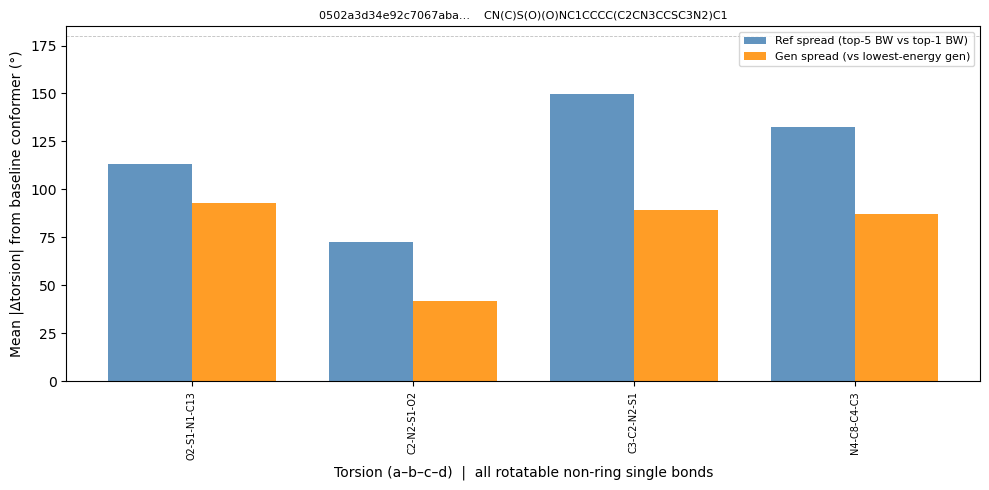

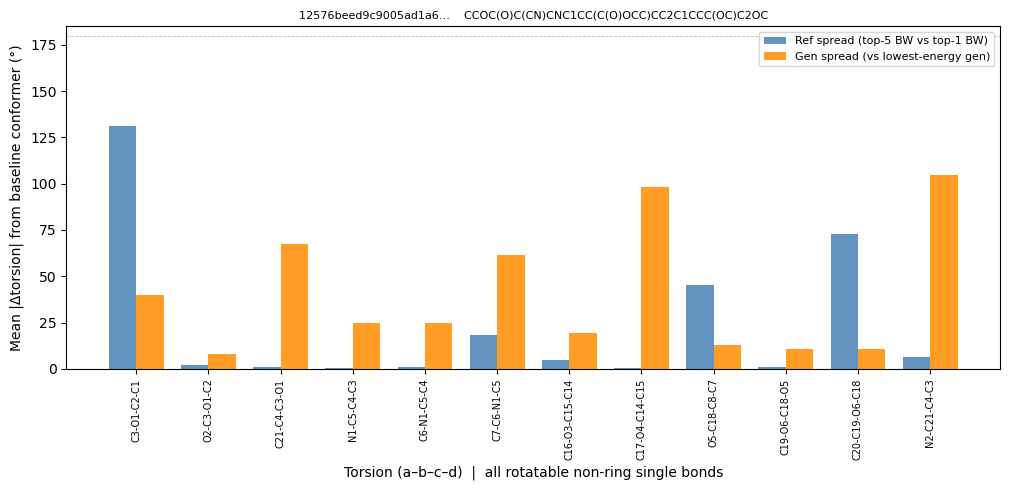

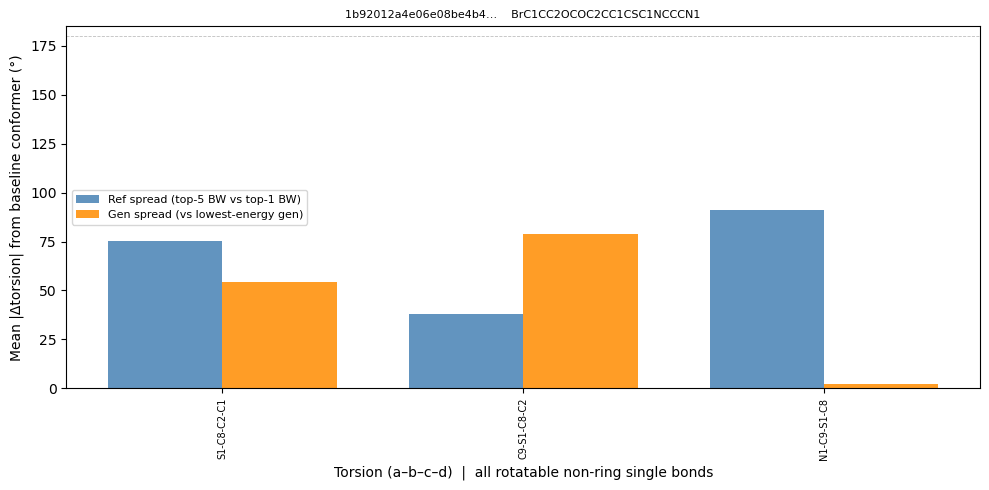

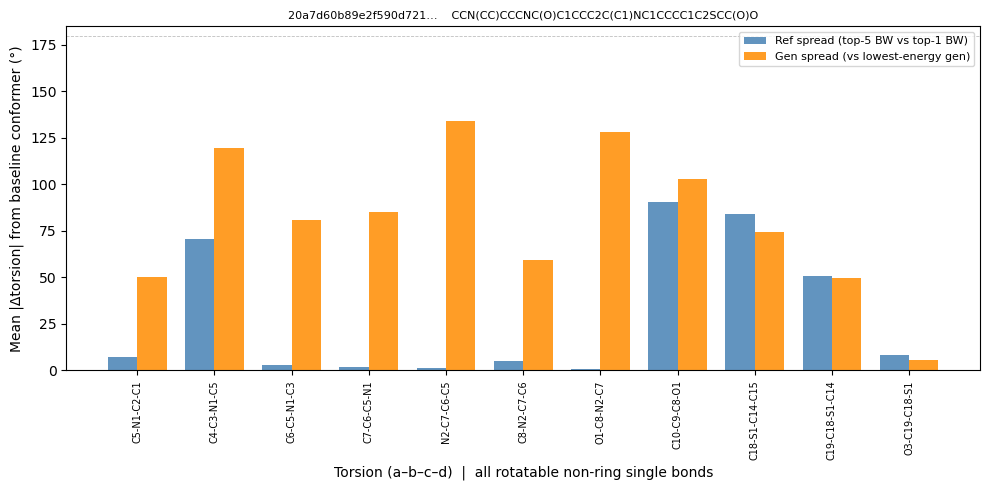

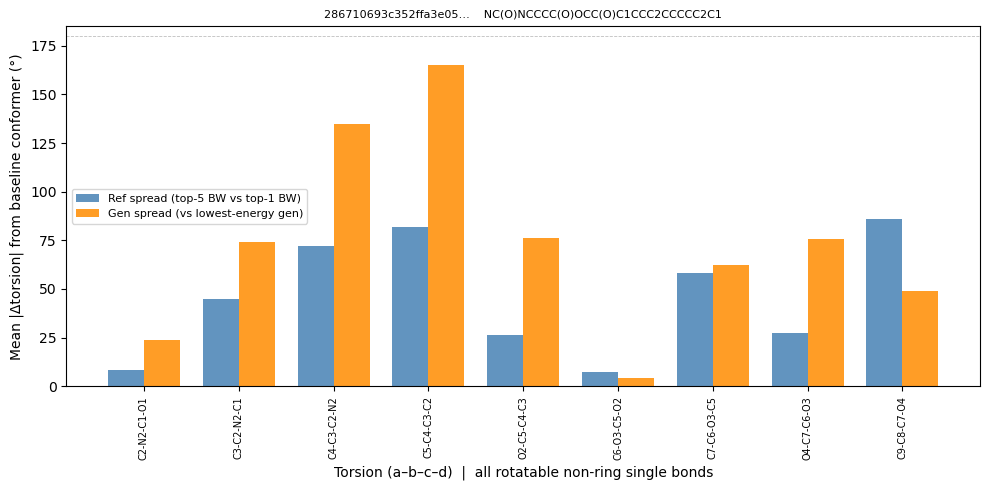

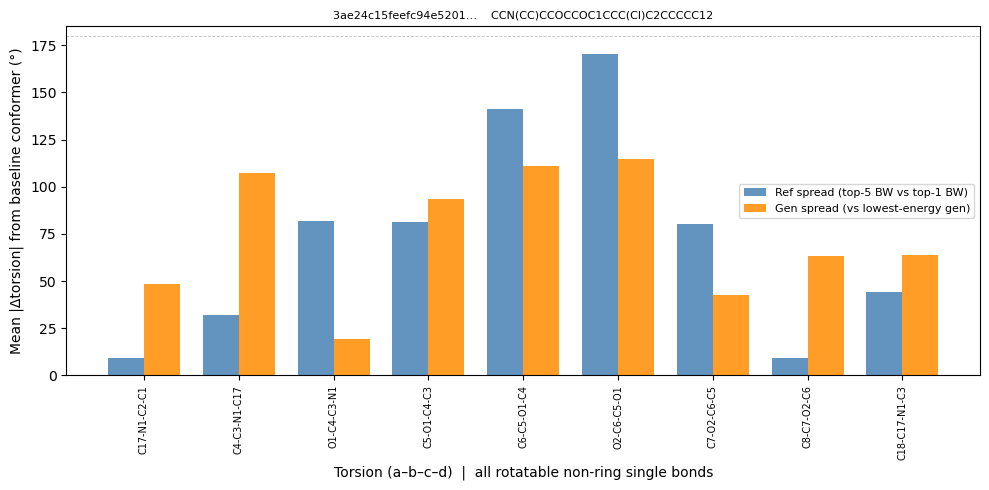

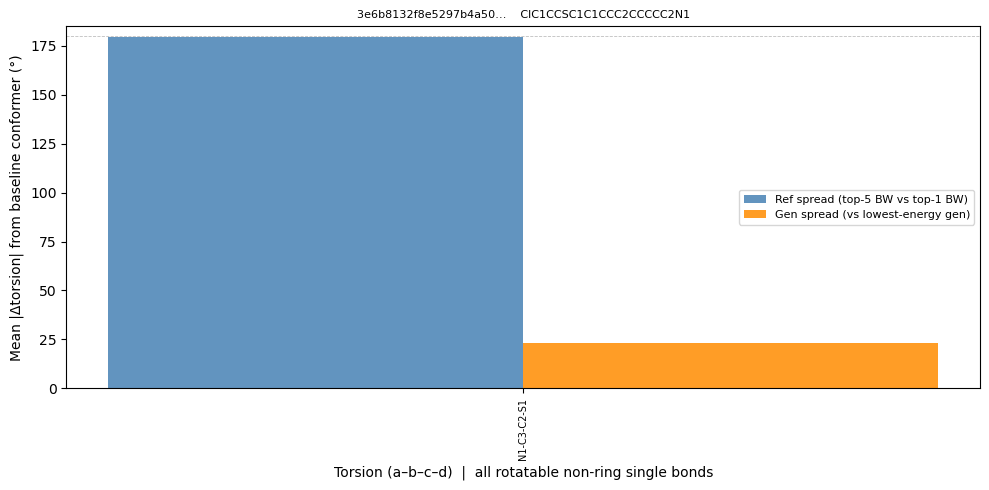

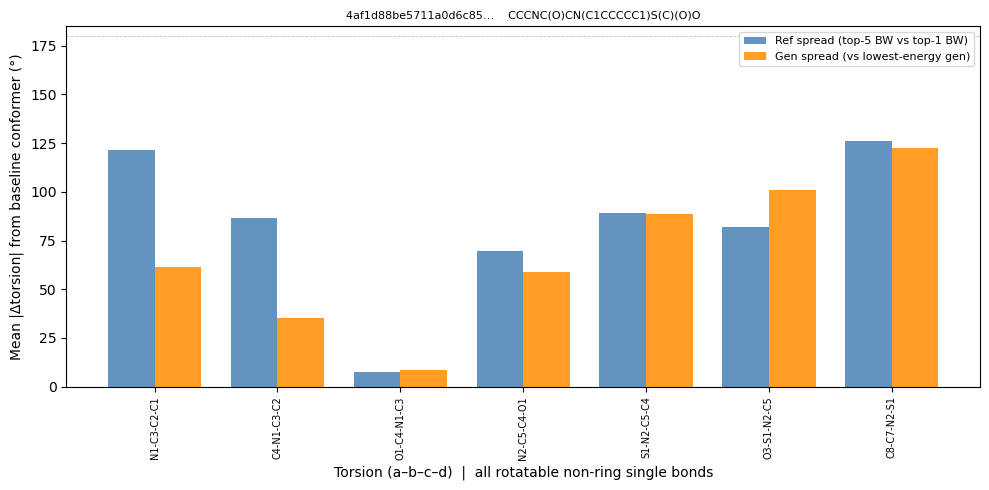

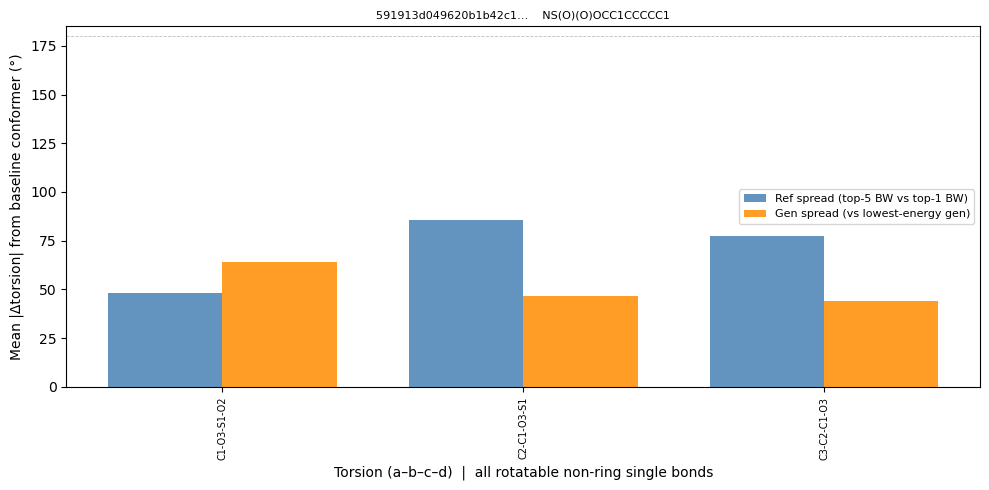

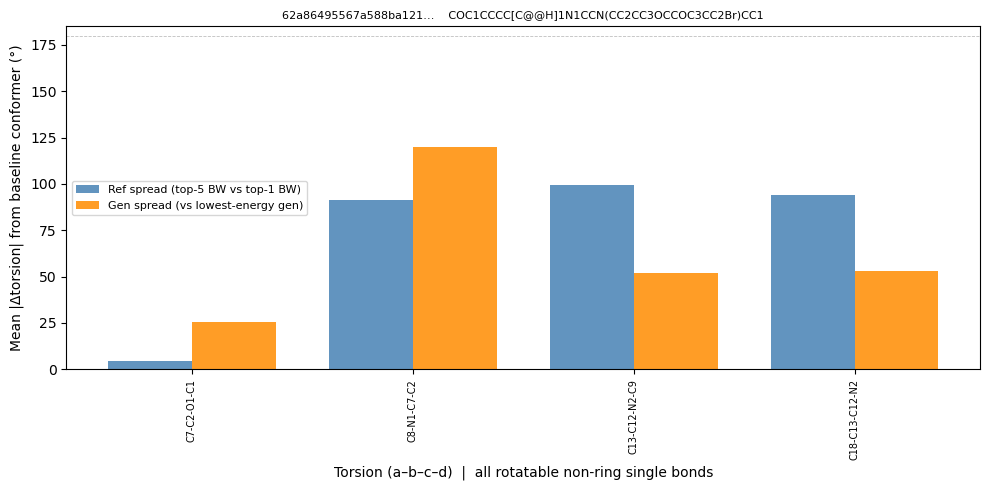

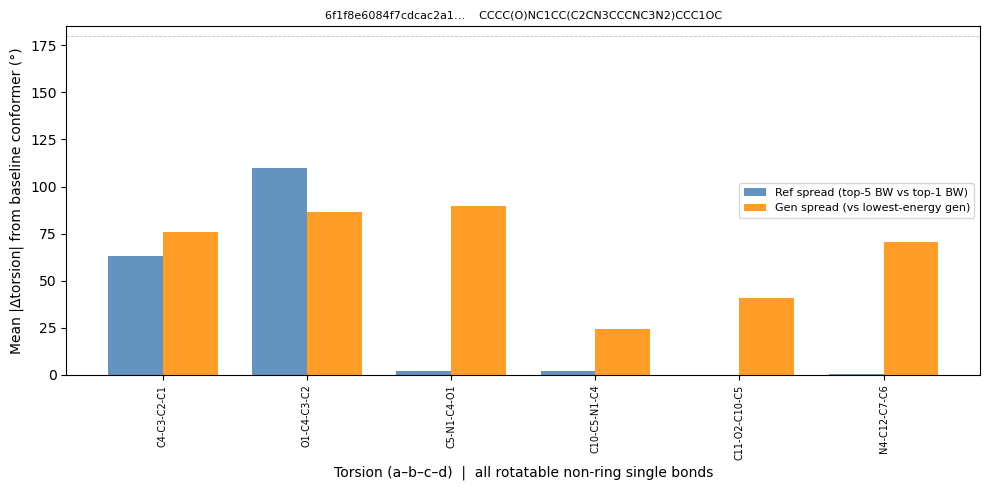

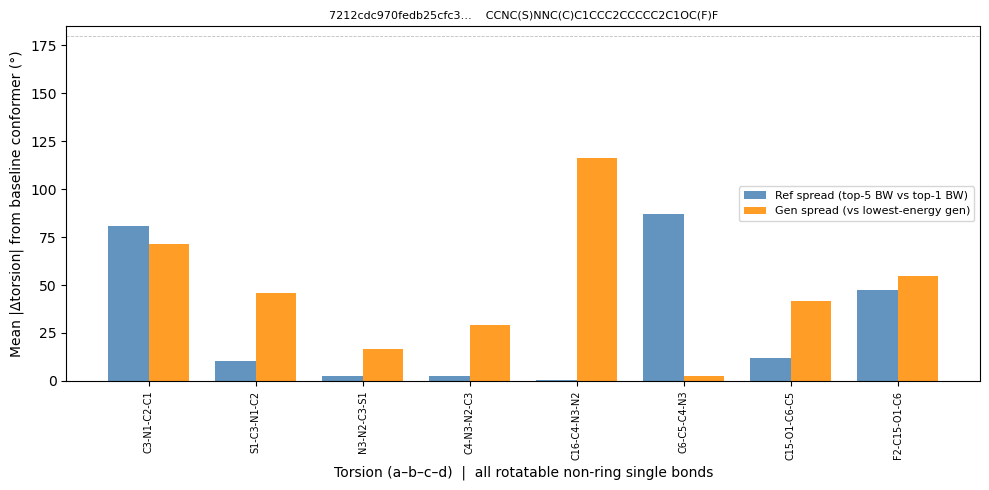

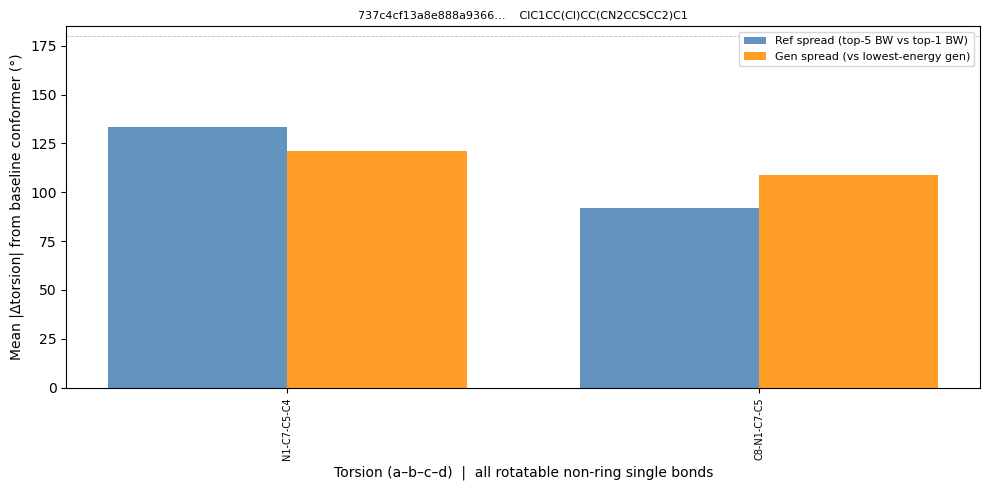

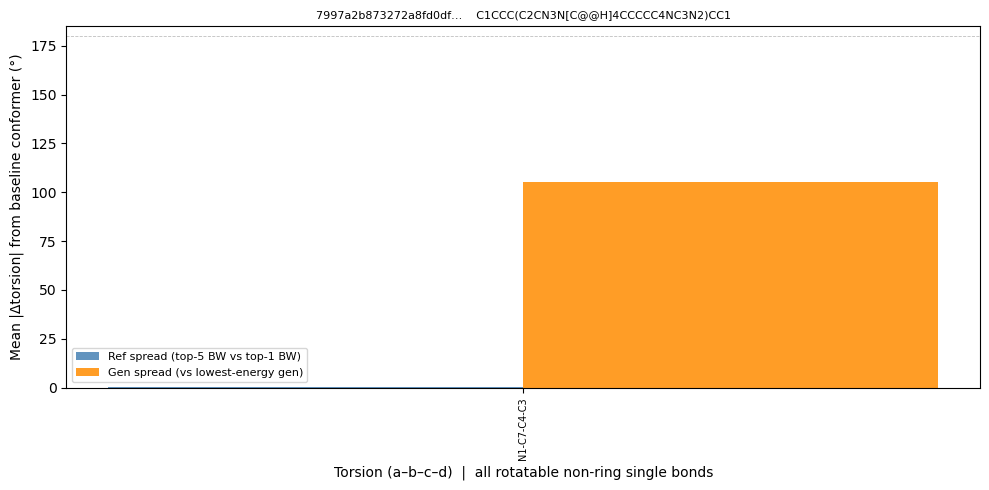

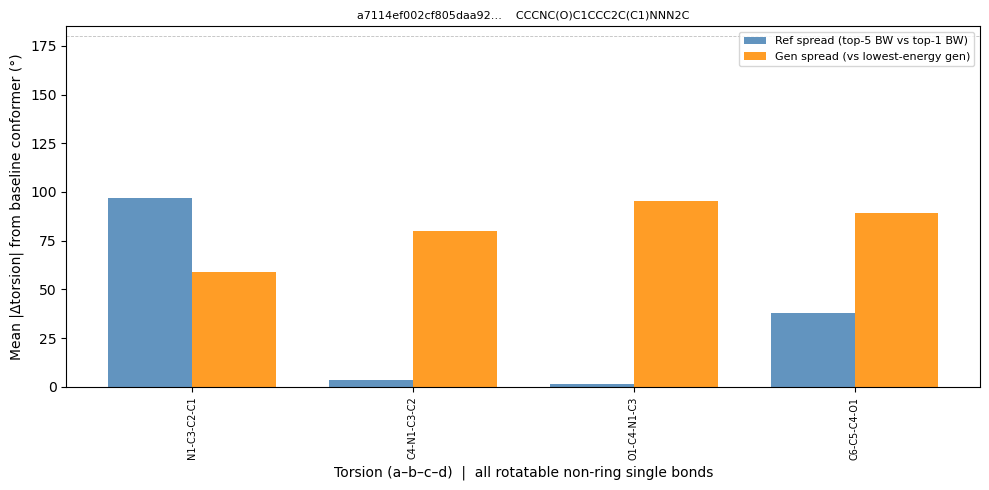

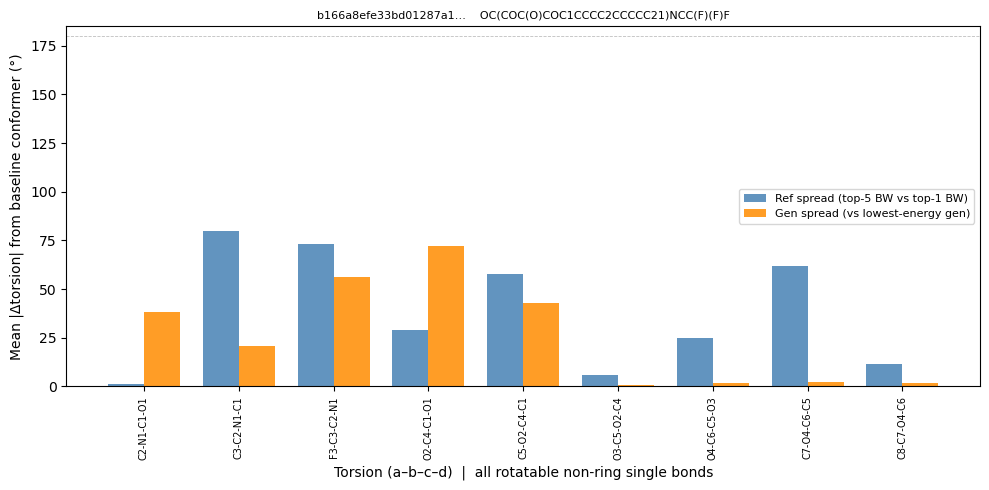

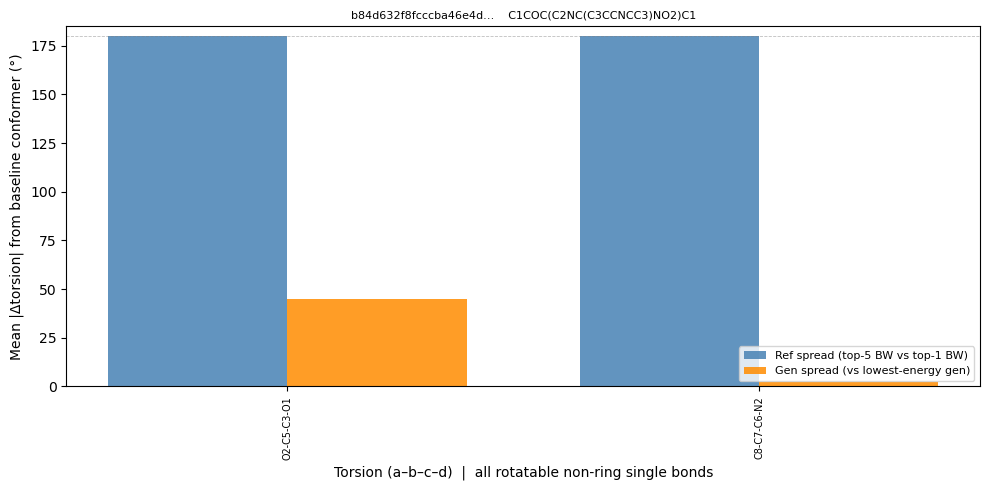

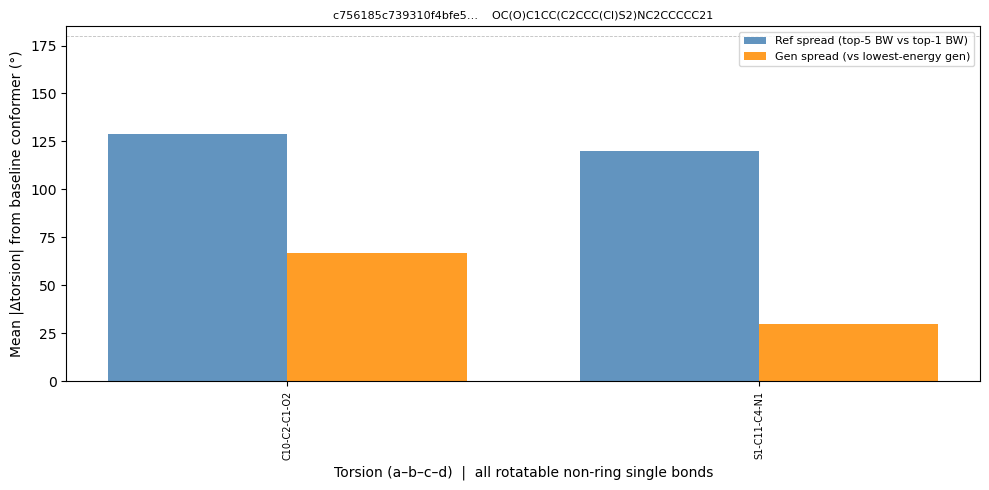

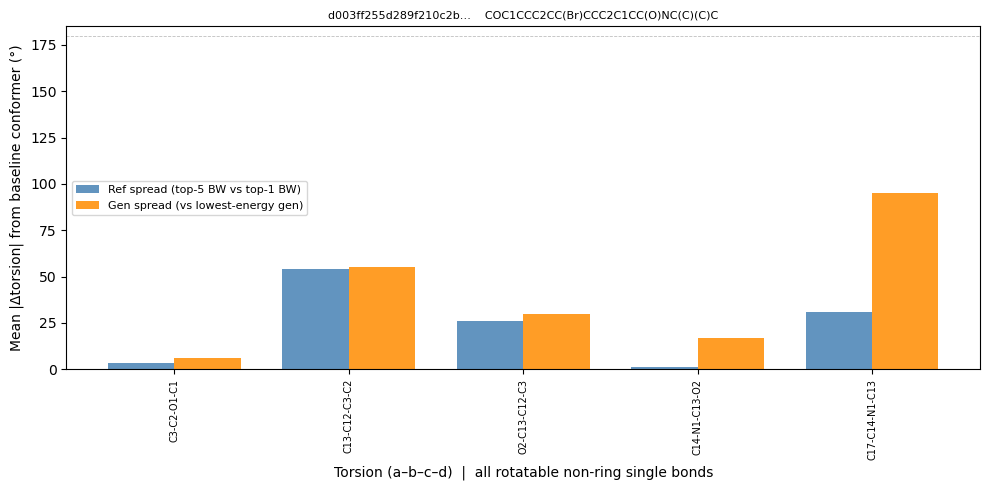

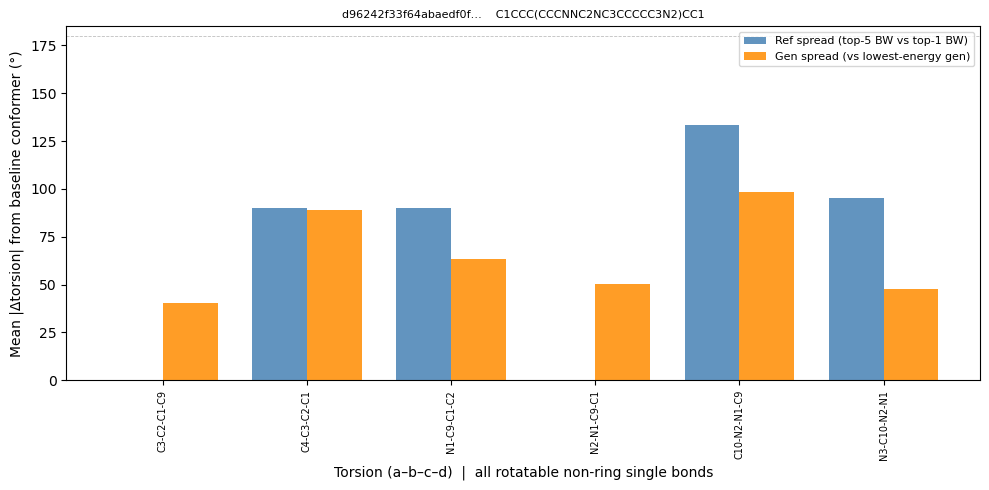

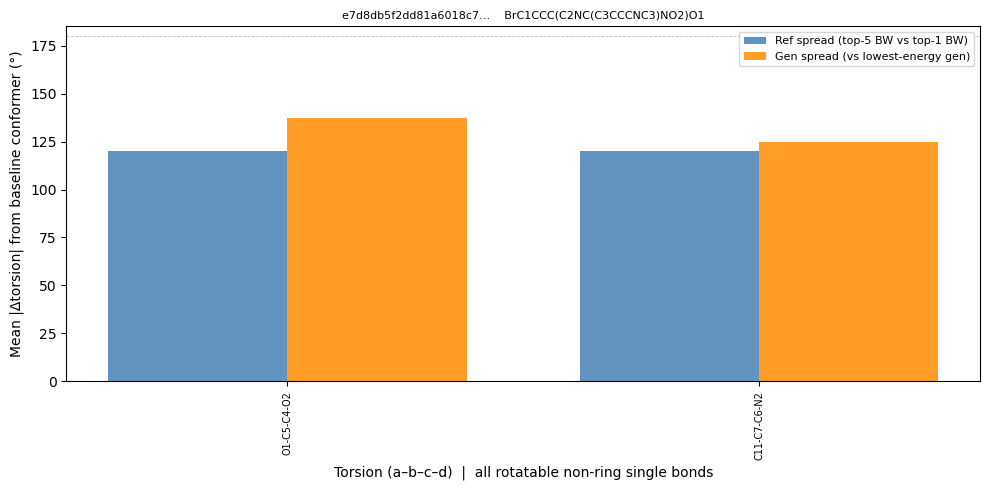

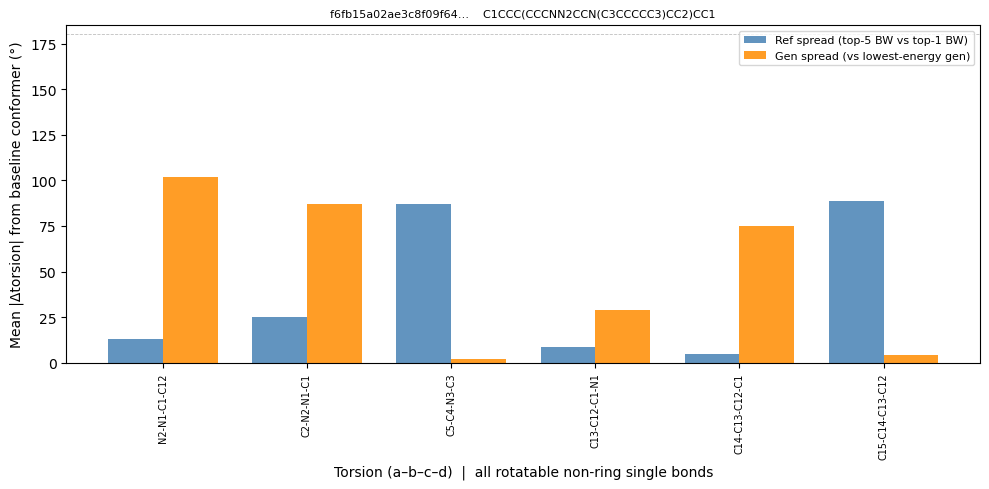

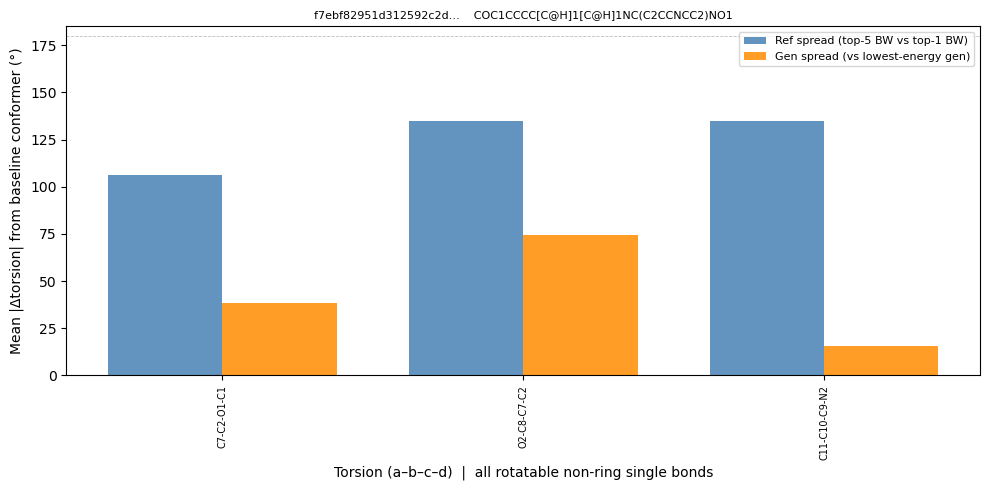

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

# ── helpers ────────────────────────────────────────────────────────────────

def assign_atom_names(mol_h):
    """Assign unique names (C1, O1, N2, …) to each heavy atom by element order."""
    counters = defaultdict(int)
    names = {}
    for atom in mol_h.GetAtoms():
        sym = atom.GetSymbol()
        counters[sym] += 1
        names[atom.GetIdx()] = f"{sym}{counters[sym]}"
    return names


def get_torsion_quads(mol_h):
    """
    Return [(a, b, c, d), …] for every rotatable bond in mol_h:
      - non-ring single bonds where both endpoints have degree >= 2
      - covers ALL such bonds (no further filtering)
    a and d are the highest CIP-priority heavy neighbours of b and c respectively,
    using the atom_priority() function defined earlier in the notebook.
    """
    quads = []
    seen = set()
    for bond in mol_h.GetBonds():
        if bond.IsInRing() or bond.GetBondType() != Chem.BondType.SINGLE:
            continue
        b, c = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        key = (min(b, c), max(b, c))
        if key in seen:
            continue
        seen.add(key)
        ab, ac = mol_h.GetAtomWithIdx(b), mol_h.GetAtomWithIdx(c)
        if ab.GetDegree() < 2 or ac.GetDegree() < 2:
            continue
        a = max(
            (n.GetIdx() for n in ab.GetNeighbors() if n.GetIdx() != c),
            key=lambda idx: atom_priority(mol_h, idx, b),
        )
        d = max(
            (n.GetIdx() for n in ac.GetNeighbors() if n.GetIdx() != b),
            key=lambda idx: atom_priority(mol_h, idx, c),
        )
        quads.append((a, b, c, d))
    return quads


def circular_diff(ang1, ang2):
    """Minimum circular difference between two dihedral angles in degrees."""
    diff = abs(ang1 - ang2) % 360
    return min(diff, 360 - diff)


def conf_torsion_angles(mol_h, quads):
    """Return {quad: dihedral_deg} for each quad in quads."""
    conf = mol_h.GetConformer()
    out = {}
    for a, b, c, d in quads:
        try:
            out[(a, b, c, d)] = rdMolTransforms.GetDihedralDeg(conf, a, b, c, d)
        except Exception:
            pass
    return out


# ── per-molecule torsion-spread computation ─────────────────────────────────
#
# Ref spread  : mean |Δtorsion| of the other top-5 BW ref conformers
#               vs the top-1 Boltzmann-weight conformer.
# Gen spread  : mean |Δtorsion| of the other 4 generated conformers
#               vs the lowest-xTB-energy generated conformer.
# Both spreads measure internal diversity within each set, using the
# most "canonical" member of that set as the baseline.
#
# Only molecules in perfect_mol_ids are included (all 5 gen conformers
# are exact connectivity+stereo+charge matches to the reference).

torsion_results = {}   # mol_id -> {torsion_name: {'ref': float, 'gen': float}}

for mol_id in sorted(perfect_mol_ids):
    # ---- reference: top-5 BW conformers ----
    ref_ents = ref_energies.get(mol_id, [])
    if not ref_ents:
        continue
    ref_ents_sorted = sorted(ref_ents, key=lambda x: x[2], reverse=True)  # desc BW
    top1_path = ref_ents_sorted[0][0]

    top1_mol, *_ = load_and_prepare(top1_path)
    if top1_mol is None:
        continue
    top1_h = Chem.RemoveHs(top1_mol)

    quads = get_torsion_quads(top1_h)
    if not quads:
        continue

    atom_names  = assign_atom_names(top1_h)
    quad_name   = {(a, b, c, d): f"{atom_names[a]}-{atom_names[b]}-{atom_names[c]}-{atom_names[d]}"
                   for a, b, c, d in quads}
    top1_angles = conf_torsion_angles(top1_h, quads)

    ref_diffs = defaultdict(list)
    for path, _, _ in ref_ents_sorted[1:]:
        mol, *_ = load_and_prepare(path)
        if mol is None:
            continue
        angs = conf_torsion_angles(Chem.RemoveHs(mol), quads)
        for q in quads:
            if q in top1_angles and q in angs:
                ref_diffs[q].append(circular_diff(top1_angles[q], angs[q]))

    # ---- generated: find lowest-energy conformer as baseline ----
    gen_ents = [(p, e) for p, e in gen_energies.get(mol_id, []) if np.isfinite(e)]
    gen_diffs = defaultdict(list)

    if gen_ents:
        gen_base_path, _ = min(gen_ents, key=lambda x: x[1])
        gen_base_mol, *_ = load_and_prepare(gen_base_path)

        if gen_base_mol is not None:
            gen_base_angles = conf_torsion_angles(Chem.RemoveHs(gen_base_mol), quads)

            for gen_path, _ in gen_ents:
                if gen_path == gen_base_path:
                    continue
                mol, *_ = load_and_prepare(gen_path)
                if mol is None:
                    continue
                angs = conf_torsion_angles(Chem.RemoveHs(mol), quads)
                for q in quads:
                    if q in gen_base_angles and q in angs:
                        gen_diffs[q].append(circular_diff(gen_base_angles[q], angs[q]))

    mol_data = {}
    for q in quads:
        name    = quad_name[q]
        ref_val = float(np.mean(ref_diffs[q])) if ref_diffs[q] else float('nan')
        gen_val = float(np.mean(gen_diffs[q])) if gen_diffs[q] else float('nan')
        mol_data[name] = {'ref': ref_val, 'gen': gen_val}

    torsion_results[mol_id] = mol_data

print(f"Torsion spread computed for {len(torsion_results)} perfectly-matched molecules.")


# ── plotting ────────────────────────────────────────────────────────────────

for mol_id, mol_data in sorted(torsion_results.items()):
    if not mol_data:
        continue

    names    = list(mol_data.keys())
    ref_vals = [mol_data[n]['ref'] for n in names]
    gen_vals = [mol_data[n]['gen'] for n in names]

    n     = len(names)
    x     = np.arange(n)
    width = 0.38

    fig, ax = plt.subplots(figsize=(max(10, n * 0.85), 5))

    ax.bar(x - width / 2, ref_vals, width, label='Ref spread (top-5 BW vs top-1 BW)',
           color='steelblue', alpha=0.85)
    ax.bar(x + width / 2, gen_vals, width, label='Gen spread (vs lowest-energy gen)',
           color='darkorange', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=90, fontsize=7)
    ax.set_xlabel('Torsion (a–b–c–d)  |  all rotatable non-ring single bonds', labelpad=4)
    ax.set_ylabel('Mean |Δtorsion| from baseline conformer (°)')
    ax.set_ylim(0, 185)
    ax.axhline(180, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

    smi   = ref_mol_id_to_display_smis.get(mol_id, ('?', '?'))[1]
    title = f"{mol_id[:20]}…    {smi}"
    ax.set_title(title, fontsize=8)

    plt.tight_layout()
    plt.show()
